In [ ]:
# Video: Ejemplo de uso de una API con Request

In [1]:
import requests

In [3]:
ciudad = "madrid"
lat=22.1498
lon=-100.9792

In [9]:
api_key="fe92611f118a14165ac92d65aaebec5e"

url = f"https://api.openweathermap.org/data/2.5/weather?q={ciudad}&appid={api_key}"

In [10]:
respuesta = requests.get(url)

In [11]:
type(respuesta)

requests.models.Response

In [12]:
data = respuesta.json()

In [14]:
type(data)

dict

In [15]:
data

{'coord': {'lon': -3.7026, 'lat': 40.4165},
 'weather': [{'id': 800,
   'main': 'Clear',
   'description': 'clear sky',
   'icon': '01n'}],
 'base': 'stations',
 'main': {'temp': 291.41,
  'feels_like': 291.3,
  'temp_min': 290.58,
  'temp_max': 291.85,
  'pressure': 1015,
  'humidity': 77,
  'sea_level': 1015,
  'grnd_level': 941},
 'visibility': 10000,
 'wind': {'speed': 6.17, 'deg': 230},
 'clouds': {'all': 0},
 'dt': 1761334808,
 'sys': {'type': 2,
  'id': 2084029,
  'country': 'ES',
  'sunrise': 1761287722,
  'sunset': 1761326540},
 'timezone': 7200,
 'id': 3117735,
 'name': 'Madrid',
 'cod': 200}

In [1]:
# Video manejo de respuesta de JSON de la api

In [2]:
import requests

In [3]:
url = "https://jsonplaceholder.typicode.com/posts/1"

In [6]:
respuesta = requests.get(url)
type(respuesta)

requests.models.Response

In [7]:
data = respuesta.json()

{'userId': 1,
 'id': 1,
 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit',
 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}

In [8]:
data["title"]

'sunt aut facere repellat provident occaecati excepturi optio reprehenderit'

In [9]:
titulo1 = data["title"]
type(str)

type

In [19]:
url2 = "https://jsonplaceholder.typicode.com/posts/"
respuesta2 = requests.get(url2)
data2 = respuesta2.json()
# data2

In [13]:
usuarios = []
for post in data2:
    usuarios.append(post["userId"])

In [18]:
# usuarios

In [15]:
import pandas as pd

In [16]:
miSerie = pd.Series(usuarios)
miSerie

0      1
1      1
2      1
3      1
4      1
      ..
95    10
96    10
97    10
98    10
99    10
Length: 100, dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x1ea50070910>,
 'caps': [<matplotlib.lines.Line2D at 0x1ea50070b90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ea50058690>],
 'medians': [<matplotlib.lines.Line2D at 0x1ea50070e10>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ea50070f50>],
 'means': []}

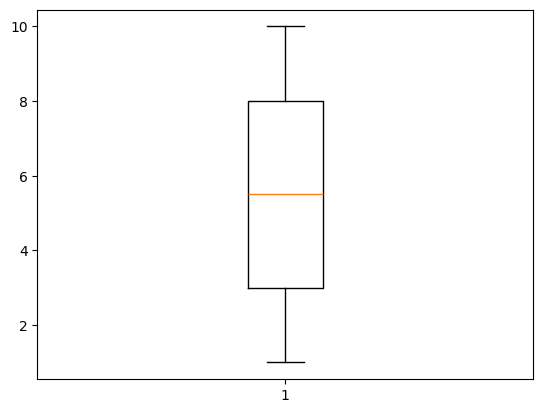

In [17]:
import matplotlib.pyplot as plt
plt.boxplot(usuarios)

In [22]:
# Video: Manejo de errores en las respuestas HTTP

In [27]:
import requests

url="https://jsonplaceholder.typicode.com/posts/a"
respuesta = requests.get(url)

In [28]:
type(respuesta)

requests.models.Response

In [29]:
respuesta.status_code

404

In [30]:
if respuesta.status_code == 200:
    data = respuesta.json()
    print(data)
else:
    print(f"Error {respuesta.status_code}: no disponemos de esa informacion")

Error 404: no disponemos de esa informacion


In [8]:
# Video: Recolectar datos usando APIs del mundo real
from IPython.display import Image, display
import pandas as pd

In [9]:
import requests
url = f"https://api.nasa.gov/planetary/apod"
api_key = "d9FfsUEeii4oPhcZKEQdg9wsI49YmledWAmEKkdJ"
params = {
    "api_key" : api_key,
    "date":"2002-03-20"
}

respuesta = requests.get(url, params=params)
data = respuesta.json()
data

{'copyright': '\nRobert Schwarz \n(U. Wisconsin)\n',
 'date': '2002-03-20',
 'explanation': 'Looking out from the bottom of the world, strange and spectacular sights are sometimes observed.  Such was the case during the long Antarctic night of 1998, as awesome aurora sub-storms were photographed above scientific outposts.  Visible in the left foreground of the above photograph is the Martin A. Pomerantz Observatory while the now defunct SPIREX telescope canvas dome is visible to its right.  The outside temperature at the time this photograph was taken was about -73 Celsius (-100 Fahrenheit), although a slightly heated box sheltered the camera.',
 'hdurl': 'https://apod.nasa.gov/apod/image/0203/spaurora1_schwarz.jpg',
 'media_type': 'image',
 'service_version': 'v1',
 'title': 'Aurora Over Antarctica',
 'url': 'https://apod.nasa.gov/apod/image/0203/spaurora1_schwarz.jpg'}

In [10]:
display(Image(url=data["url"]))

In [11]:
url="https://api.nasa.gov/DONKI/IPS?"

def obtener_donki(fecha_inicio, fecha_fin):
    params= {
        "api_key": api_key,
        "startDate": fecha_inicio,
        "endDate": fecha_fin
    }
    respuesta =  requests.get(url, params = params)
    data = respuesta.json()
    return pd.DataFrame(data)

In [13]:
df = obtener_donki("2023-12-01","2023-12-31")
df

,catalog,activityID,location,eventTime,submissionTime,versionId,link,instruments,linkedEvents,sentNotifications
0,M2M_CATALOG,2023-12-01T00:11:00-IPS-001,STEREO A,2023-12-01T00:11Z,2023-12-06T02:01Z,4,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,"[{'displayName': 'STEREO A: IMPACT'}, {'displa...",[{'activityID': '2023-11-27T20:12:00-CME-001'}...,None
1,M2M_CATALOG,2023-12-01T08:15:00-IPS-001,STEREO A,2023-12-01T08:15Z,2023-12-06T02:52Z,3,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,"[{'displayName': 'STEREO A: IMPACT'}, {'displa...",[{'activityID': '2023-11-28T20:24:00-CME-001'}...,None
2,M2M_CATALOG,2023-12-01T08:48:00-IPS-001,Earth,2023-12-01T08:48Z,2023-12-06T03:58Z,5,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,"[{'displayName': 'DSCOVR: PLASMAG'}, {'display...",[{'activityID': '2023-11-28T20:24:00-CME-001'}...,"[{'messageID': '20231201-AL-004', 'messageIssu..."
3,M2M_CATALOG,2023-12-04T04:30:00-IPS-001,Earth,2023-12-04T04:30Z,2023-12-05T17:02Z,2,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,"[{'displayName': 'DSCOVR: PLASMAG'}, {'display...",[{'activityID': '2023-12-01T22:24:00-CME-001'}],None
4,M2M_CATALOG,2023-12-04T08:09:00-IPS-001,STEREO A,2023-12-04T08:09Z,2023-12-05T18:23Z,3,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,"[{'displayName': 'STEREO A: IMPACT'}, {'displa...",[{'activityID': '2023-12-01T22:24:00-CME-001'}],None
5,M2M_CATALOG,2023-12-09T19:27:00-IPS-001,Mars,2023-12-09T19:27Z,2024-01-10T17:22Z,1,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,"[{'displayName': 'MAVEN: SEP'}, {'displayName'...",[{'activityID': '2023-12-07T13:36:00-CME-001'}],None
6,M2M_CATALOG,2023-12-12T11:26:00-IPS-001,Earth,2023-12-12T11:26Z,2023-12-13T02:20Z,5,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,"[{'displayName': 'DSCOVR: PLASMAG'}, {'display...",None,"[{'messageID': '20231212-AL-001', 'messageIssu..."
7,M2M_CATALOG,2023-12-13T00:00:00-IPS-001,STEREO A,2023-12-13T00:00Z,2023-12-13T22:17Z,2,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,"[{'displayName': 'STEREO A: IMPACT'}, {'displa...",None,None
8,M2M_CATALOG,2023-12-13T21:54:00-IPS-001,Earth,2023-12-13T21:54Z,2023-12-20T18:14Z,2,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,[{'displayName': 'DSCOVR: PLASMAG'}],[{'activityID': '2023-12-14T04:51:00-MPC-001'}],None
9,M2M_CATALOG,2023-12-15T10:57:00-IPS-001,Earth,2023-12-15T10:57Z,2023-12-15T17:21Z,2,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,"[{'displayName': 'DSCOVR: PLASMAG'}, {'display...",[{'activityID': '2023-12-12T00:00:00-CME-001'}...,"[{'messageID': '20231215-AL-006', 'messageIssu..."
